<a href="https://colab.research.google.com/github/jl17243-commits/Advanced-Learning/blob/main/Final_project_part_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers==4.40.0 "datasets<3.0.0" torch scikit-learn numpy matplotlib

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 137.6/137.6 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.0/9.0 MB 65.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 45.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 94.3 MB/s eta 0:00:00
  Attempting uninstall: fsspec
    Found existing installation: fsspec 2025.3.0
    Uninstalling fsspec-2025.3.0:
      Successfully uninstalled fsspec-2025.3.0
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.1
    Uninstalling huggingface_hub-1.10.1:
      Successfully uninstalled huggingface_hub-1.10.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from transformers import DistilBertTokenizerFast,AutoTokenizer
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader
import torch
import warnings
warnings.filterwarnings("ignore")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

In [46]:
from huggingface_hub import login
from google.colab import userdata
login(token=userdata.get("HF_TOKEN"))
dataset = load_dataset("takala/financial_phrasebank", "sentences_allagree", trust_remote_code=True)
print(dataset['train'][0:3])



{'sentence': ['According to Gran , the company has no plans to move all production to Russia , although that is where the company is growing .', "For the last quarter of 2010 , Componenta 's net sales doubled to EUR131m from EUR76m for the same period a year earlier , while it moved to a zero pre-tax profit from a pre-tax loss of EUR7m .", 'In the third quarter of 2010 , net sales increased by 5.2 % to EUR 205.5 mn , and operating profit by 34.9 % to EUR 23.5 mn .'], 'label': [1, 2, 2]}


In [4]:
label_names=['negative','neutral','positive']
labels_all=dataset['train']['label']
unique,counts=np.unique(labels_all,return_counts=True)
total=len(labels_all)
print("\n Label Distribution：")
print(f"{'Class':<12} {'Number':>6} {'Percentage':>8}")
print("-" * 28)
for u, c in zip(unique, counts):
    print(f"{label_names[u]:<12} {c:>6}   {c/total*100:>6.1f}%")
print(f"{'total':<12} {total:>6}   100.0%")

split1=dataset["train"].train_test_split(test_size=0.2, seed=SEED)
split2=split1['train'].train_test_split(test_size=0.1, seed=SEED)
train_dataset=split2['train']
test_dataset=split1['test']
val_dataset=split2['test']


 Label Distribution：
Class        Number Percentage
----------------------------
negative        303     13.4%
neutral        1391     61.4%
positive        570     25.2%
total          2264   100.0%


# Model 1

In [5]:
model_name="distilbert-base-uncased"
tokenizer=DistilBertTokenizerFast.from_pretrained(model_name)

def tokenize_fn(batch):
  return tokenizer(batch['sentence'], padding='max_length',max_length=128, truncation=True)

cols=['input_ids','attention_mask','label']
train_tok=train_dataset.map(tokenize_fn,batched=True)
val_tok=val_dataset.map(tokenize_fn,batched=True)
test_tok=test_dataset.map(tokenize_fn,batched=True)

for ds in [train_tok,val_tok,test_tok]:
  ds.set_format(type='torch',columns=cols)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

Map:   0%|          | 0/1629 [00:00<?, ? examples/s]

Map:   0%|          | 0/182 [00:00<?, ? examples/s]

Map:   0%|          | 0/453 [00:00<?, ? examples/s]

In [6]:
BATCH_SIZE=32
train_loader=DataLoader(train_tok,batch_size=BATCH_SIZE,shuffle=True)
val_loader=DataLoader(val_tok,batch_size=BATCH_SIZE)
test_loader=DataLoader(test_tok,batch_size=BATCH_SIZE)

In [7]:
from transformers import AutoModelForSequenceClassification

NUM_LABELS=3
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
model_pt=AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=NUM_LABELS)
model_pt.to(device)
model_pt.eval()

Device: cuda


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [8]:
from sklearn.metrics import accuracy_score,f1_score,classification_report,confusion_matrix
def evaluate(model,loader,label_names=['negative','neutral','positive']):
  model.eval()
  all_preds,all_labels=[],[]
  with torch.no_grad():
    for batch in loader:
      input_ids=batch["input_ids"].to(device)
      attention_mask=batch["attention_mask"].to(device)
      labels=batch["label"]
      logits=model(input_ids=input_ids,attention_mask=attention_mask).logits
      preds=torch.argmax(logits,dim=1).cpu()
      all_preds.extend(preds.numpy())
      all_labels.extend(labels.numpy())
  acc=accuracy_score(all_labels,all_preds)
  f1=f1_score(all_labels,all_preds,average="weighted")
  return acc,f1,all_labels,all_preds

In [9]:
acc,f1,all_labels,all_preds=evaluate(model_pt,test_loader)
print("="*45)
print("Model PT (base model)")
print("="*45)
print(f"Accuracy:{acc:.4f}")
print(f"F1 Score:{f1:.4f}")
print()
print(classification_report(all_labels,all_preds,target_names=label_names))


Model PT (base model)
Accuracy:0.3355
F1 Score:0.3530

              precision    recall  f1-score   support

    negative       0.12      0.30      0.18        73
     neutral       0.81      0.24      0.37       280
    positive       0.32      0.62      0.42       100

    accuracy                           0.34       453
   macro avg       0.42      0.39      0.32       453
weighted avg       0.59      0.34      0.35       453



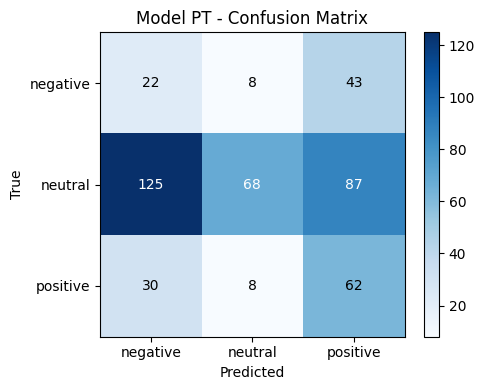

In [10]:
cm=confusion_matrix(all_labels,all_preds)
fig,ax=plt.subplots(figsize=(5,4))
im=ax.imshow(cm,cmap="Blues")
plt.colorbar(im,ax=ax)
ax.set_xticks(range(3))
ax.set_yticks(range(3))
ax.set_xticklabels(label_names)
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Model PT - Confusion Matrix")
for i in range(3):
  for j in range(3):
    ax.text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()/2 else "black")
plt.tight_layout()
plt.show()

In [11]:
results={}
results["Model PT"]={"accuracy":acc,"f1":f1}

# Model 2

In [12]:
from transformers import AutoModelForSequenceClassification
import torch.nn as nn
model_ft_head=AutoModelForSequenceClassification.from_pretrained(model_name,num_labels=NUM_LABELS,)

for param in model_ft_head.distilbert.parameters():
  param.requires_grad=False

total_params=sum(p.numel() for p in model_ft_head.parameters())
trainable_params=sum(p.numel() for p in model_ft_head.parameters() if p.requires_grad)
frozen_params=total_params-trainable_params

print("="*45)
print("Model PT + FT Classifier")
print("="*45)
print(f"Total Parameters: {total_params:,}")
print(f"Trainable Parameters: {trainable_params:,}")
print(f"Frozen Parameters: {frozen_params:,}")
print()
model_ft_head.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Model PT + FT Classifier
Total Parameters: 66,955,779
Trainable Parameters: 592,899
Frozen Parameters: 66,362,880



DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [13]:
from torch.optim import AdamW
from torch.optim.lr_scheduler import ReduceLROnPlateau

EPOCHS=10
LR=2e-3

optimizer=AdamW(
  filter(lambda p:p.requires_grad,model_ft_head.parameters()),
  lr=LR,
  weight_decay=0.01
)

scheduler=ReduceLROnPlateau(optimizer,mode="max",patience=2,factor=0.5)
criterion=nn.CrossEntropyLoss()

In [14]:
best_val_f1=0.0
best_state=None
train_losses=[]
val_f1_scores=[]

for epoch in range(EPOCHS):
  model_ft_head.train()
  running_loss=0.0

  for batch in train_loader:
    input_ids=batch["input_ids"].to(device)
    attention_mask=batch["attention_mask"].to(device)
    labels=batch["label"].to(device)

    optimizer.zero_grad()
    outputs=model_ft_head(input_ids=input_ids,attention_mask=attention_mask)
    loss=criterion(outputs.logits,labels)
    loss.backward()
    optimizer.step()

    running_loss+=loss.item()

  avg_loss=running_loss/len(train_loader)
  train_losses.append(avg_loss)

  val_acc,val_f1,_,_=evaluate(model_ft_head,val_loader)
  val_f1_scores.append(val_f1)
  scheduler.step(val_f1)

  if val_f1>best_val_f1:
    best_val_f1=val_f1
    best_state={k:v.clone() for k,v in model_ft_head.state_dict().items()}

  print(f"Epoch {epoch+1:02d}/{EPOCHS} | "
          f"Loss: {avg_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}"
          + (" ← best" if val_f1 == best_val_f1 else ""))

Epoch 01/10 | Loss: 0.5869 | Val Acc: 0.7747 | Val F1: 0.7531 ← best
Epoch 02/10 | Loss: 0.4067 | Val Acc: 0.8297 | Val F1: 0.8269 ← best
Epoch 03/10 | Loss: 0.3509 | Val Acc: 0.7747 | Val F1: 0.7706
Epoch 04/10 | Loss: 0.3387 | Val Acc: 0.8571 | Val F1: 0.8478 ← best
Epoch 05/10 | Loss: 0.3000 | Val Acc: 0.8571 | Val F1: 0.8489 ← best
Epoch 06/10 | Loss: 0.3029 | Val Acc: 0.8736 | Val F1: 0.8748 ← best
Epoch 07/10 | Loss: 0.3043 | Val Acc: 0.8571 | Val F1: 0.8574
Epoch 08/10 | Loss: 0.2707 | Val Acc: 0.8462 | Val F1: 0.8346
Epoch 09/10 | Loss: 0.2626 | Val Acc: 0.8736 | Val F1: 0.8646
Epoch 10/10 | Loss: 0.2424 | Val Acc: 0.8901 | Val F1: 0.8857 ← best


In [15]:
model_ft_head.load_state_dict(best_state)
acc,f1,all_labels,all_preds=evaluate(model_ft_head,test_loader)
print("\n" + "=" * 45)
print("  Model PT + FT Classifier Valuation")
print("=" * 45)
print(f"  Accuracy : {acc:.4f}")
print(f"  F1 Score : {f1:.4f}")
print()
print(classification_report(all_labels, all_preds, target_names=label_names))
results["Model PT + FT Classifier"]={"accuracy":acc,"f1":f1}



  Model PT + FT Classifier Valuation
  Accuracy : 0.8720
  F1 Score : 0.8722

              precision    recall  f1-score   support

    negative       0.92      0.64      0.76        73
     neutral       0.95      0.95      0.95       280
    positive       0.68      0.83      0.75       100

    accuracy                           0.87       453
   macro avg       0.85      0.81      0.82       453
weighted avg       0.88      0.87      0.87       453



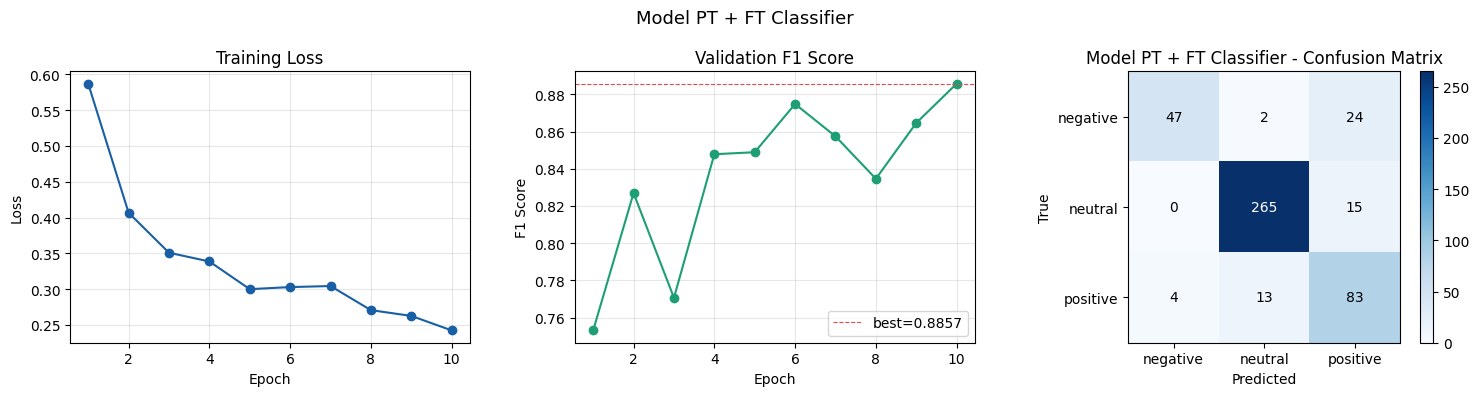

In [16]:
fig,axes=plt.subplots(1,3,figsize=(15,4))
axes[0].plot(range(1,EPOCHS+1),train_losses,marker="o",color="#185FA5")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(range(1,EPOCHS+1),val_f1_scores,marker="o",color="#1D9E75")
axes[1].axhline(best_val_f1,linestyle="--",color="#E24B4A",linewidth=0.8,label=f"best={best_val_f1:.4f}")
axes[1].set_title("Validation F1 Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1 Score")
axes[1].legend()
axes[1].grid(alpha=0.3)

cm=confusion_matrix(all_labels,all_preds)
im=axes[2].imshow(cm,cmap="Blues")
plt.colorbar(im,ax=axes[2])
axes[2].set_xticks(range(3))
axes[2].set_yticks(range(3))
axes[2].set_xticklabels(label_names)
axes[2].set_yticklabels(label_names)
axes[2].set_xlabel("Predicted")
axes[2].set_ylabel("True")
axes[2].set_title("Model PT + FT Classifier - Confusion Matrix")
for i in range(3):
  for j in range(3):
    axes[2].text(j,i,cm[i,j],ha="center",va="center",color="white" if cm[i,j]>cm.max()/2 else "black")
plt.suptitle("Model PT + FT Classifier",fontsize=13)
plt.tight_layout()
plt.show()


## Model 3: Custom Classifier Head — Required Explanations

### 1. How is this head different from the original?

The original classifier head in `DistilBertForSequenceClassification` is:

**Linear(768 → 768) → GELU → Dropout(0.1) → Linear(768 → 3)**

Our custom head differs in three key ways:

**Dimensionality Reduction**: Instead of keeping the hidden dimension at 768 throughout, we progressively compress it from 768 → 512. This reduces redundant feature dimensions and forces the network to extract more compact, discriminative representations.

**LayerNorm after every Linear layer**: The original head has no normalization between layers. We add `LayerNorm` after each `Linear` layer, which stabilizes the distribution of activations and is consistent with the normalization style used inside the DistilBERT body itself.

**Residual Connection**: The original head has no skip connections. We add a residual connection in the second block (`x = x + residual`), which provides a gradient highway during backpropagation and prevents the vanishing gradient problem as the head becomes deeper.

Our custom head structure:

**[CLS] token (768)
→ Linear(768 → 512) + LayerNorm(512) + GELU + Dropout(0.3)
→ Residual Block: Linear(512 → 512) + LayerNorm(512) + GELU + Dropout(0.2)
→ Linear(512 → 3)**

---

### 2. What inspired these design choices?

**Why LayerNorm (not BatchNorm)?**
DistilBERT's body uses `LayerNorm` internally throughout all 6 Transformer layers. Extending this same normalization style into the classifier head creates architectural consistency — gradients flow through a uniform normalization landscape from the output all the way back into the body. `BatchNorm` depends on batch statistics and behaves differently during training vs inference, which is undesirable in NLP settings where sequences are often processed one at a time.

**Why a residual connection?**
The residual connection was inspired directly by the Transformer architecture itself. Every layer inside DistilBERT wraps its sub-components (self-attention, FFN) with residual connections. By introducing a residual block in our classifier head, we extend this design principle beyond the body — ensuring that even if the linear transformation in layer 2 is unhelpful early in training, the original representation can still pass through unchanged.

**Why progressive dimensionality reduction (768 → 512 → 3)?**
This design was inspired by the information bottleneck principle. Gradually compressing the representation forces the network to retain only the most discriminative features for sentiment classification, rather than directly classifying from a high-dimensional space where noise may dominate.

---

### 3. Technical challenges of grafting the head onto the pre-existing body

**Challenge 1 — Interface alignment**
The DistilBERT body outputs a tensor of shape `(batch_size, seq_len, 768)`. Our custom head expects a 1D vector per sample of exactly 768 dimensions. We must correctly extract the `[CLS]` token representation using:
```python
cls_output = outputs.last_hidden_state[:, 0, :]   # shape: (batch, 768)
```
If the wrong token position is selected or the tensor is not properly sliced, the head will receive the wrong input shape and the `Linear(768 → 512)` layer will throw a dimension mismatch error.

**Challenge 2 — Bypassing the original forward logic**
`AutoModelForSequenceClassification` has its own `forward()` method that internally calls its built-in classifier head. We cannot simply swap out the head and reuse this forward method. Instead, we must use `DistilBertModel` (body only, no head) and write our own `forward()` that explicitly controls the full pipeline:

**tokenized input
→ DistilBERT body hidden states
→ [CLS] token extraction
→ custom head
→ logits**

This requires understanding the HuggingFace model API well enough to know which output attribute (`last_hidden_state`) to access, and how to correctly compose the two modules into a single `nn.Module`.

In [17]:
import torch.nn as nn
class CustomClassifierHead(nn.Module):
  def __init__(self,input_dim=768,hidden_dim=512,num_labels=3):
    super().__init__()

    self.layer1=nn.Sequential(
        nn.Linear(input_dim,hidden_dim),
        nn.LayerNorm(hidden_dim),
        nn.GELU(),
        nn.Dropout(0.3),
    )

    self.layer2_main=nn.Sequential(
        nn.Linear(hidden_dim,hidden_dim),
        nn.LayerNorm(hidden_dim),
        nn.GELU(),
        nn.Dropout(0.2),
    )
    self.output=nn.Linear(hidden_dim,num_labels)

  def forward(self,x):
    x=self.layer1(x)
    residual=x
    x=self.layer2_main(x)
    x=x+residual
    x=self.output(x)
    return x


In [18]:
from transformers import DistilBertModel
class DistilBertWithCustomHead(nn.Module):
  def __init__(self,model_name,num_labels=3):
    super().__init__()

    self.distilbert=DistilBertModel.from_pretrained(model_name)
    self.classifier=CustomClassifierHead(input_dim=768,hidden_dim=512,num_labels=num_labels)
    for param in self.distilbert.parameters():
      param.requires_grad=False

  def forward(self,input_ids,attention_mask):
    outputs=self.distilbert(input_ids=input_ids,attention_mask=attention_mask)
    cls_output=outputs.last_hidden_state[:,0,:]
    logits=self.classifier(cls_output)
    return logits

In [19]:
model_own_head=DistilBertWithCustomHead(model_name=model_name,num_labels=NUM_LABELS)
model_own_head.to(device)

total_params=sum(p.numel() for p in model_own_head.parameters())
trainable_params=sum(p.numel() for p in model_own_head.parameters() if p.requires_grad)
frozen_params=total_params-trainable_params

print("=" * 45)
print("  Model 3 parameters")
print("=" * 45)
print(f"  total params    : {total_params:,}")
print(f"  trainable params  : {trainable_params:,}")
print(f"  frozen params    : {frozen_params:,}")

  Model 3 parameters
  total params    : 67,022,851
  trainable params  : 659,971
  frozen params    : 66,362,880


In [20]:
EPOCHS_M3=10
LR_M3=2e-3

optimizer_m3=AdamW(
  filter(lambda p:p.requires_grad,model_own_head.parameters()),
  lr=LR_M3,
  weight_decay=0.01
)
scheduler_m3=ReduceLROnPlateau(optimizer_m3,mode="max",patience=2,factor=0.5)
criterion_m3=nn.CrossEntropyLoss()

In [21]:
best_val_f1_m3=0.0
best_state_m3=None
train_losses_m3=[]
val_f1_score_m3=[]

for epoch in range(EPOCHS_M3):
  model_own_head.train()
  running_loss=0.0

  for batch in train_loader:
    input_ids=batch['input_ids'].to(device)
    attention_mask=batch['attention_mask'].to(device)
    labels=batch['label'].to(device)

    optimizer_m3.zero_grad()
    logits=model_own_head(input_ids,attention_mask)
    loss=criterion_m3(logits,labels)
    loss.backward()
    optimizer_m3.step()
    running_loss+=loss.item()

  avg_loss=running_loss/len(train_loader)
  train_losses_m3.append(avg_loss)

  model_own_head.eval()
  all_preds_val,all_labels_val=[],[]
  with torch.no_grad():
    for batch in val_loader:
      input_ids=batch["input_ids"].to(device)
      attention_mask=batch["attention_mask"].to(device)
      labels=batch["label"]
      logits=model_own_head(input_ids,attention_mask)
      preds=torch.argmax(logits,dim=-1).cpu()
      all_preds_val.extend(preds.numpy())
      all_labels_val.extend(labels.numpy())
  val_acc=accuracy_score(all_labels_val,all_preds_val)
  val_f1=f1_score(all_labels_val,all_preds_val,average="weighted")
  val_f1_score_m3.append(val_f1)
  scheduler_m3.step(val_f1)

  if val_f1 > best_val_f1_m3:
        best_val_f1_m3 = val_f1
        best_state_m3  = {k: v.clone() for k, v in model_own_head.state_dict().items()}

  print(f"Epoch {epoch+1:02d}/{EPOCHS_M3} | "
        f"Loss: {avg_loss:.4f} | "
        f"Val Acc: {val_acc:.4f} | "
        f"Val F1: {val_f1:.4f}"
        + (" ← best" if val_f1 == best_val_f1_m3 else ""))


Epoch 01/10 | Loss: 0.7883 | Val Acc: 0.7308 | Val F1: 0.6960 ← best
Epoch 02/10 | Loss: 0.4988 | Val Acc: 0.7912 | Val F1: 0.7728 ← best
Epoch 03/10 | Loss: 0.4139 | Val Acc: 0.7692 | Val F1: 0.7820 ← best
Epoch 04/10 | Loss: 0.3902 | Val Acc: 0.8132 | Val F1: 0.7960 ← best
Epoch 05/10 | Loss: 0.3772 | Val Acc: 0.8462 | Val F1: 0.8407 ← best
Epoch 06/10 | Loss: 0.2966 | Val Acc: 0.8516 | Val F1: 0.8427 ← best
Epoch 07/10 | Loss: 0.3368 | Val Acc: 0.8242 | Val F1: 0.8343
Epoch 08/10 | Loss: 0.2769 | Val Acc: 0.8626 | Val F1: 0.8630 ← best
Epoch 09/10 | Loss: 0.3013 | Val Acc: 0.8626 | Val F1: 0.8519
Epoch 10/10 | Loss: 0.2502 | Val Acc: 0.8352 | Val F1: 0.8221


In [22]:

model_own_head.load_state_dict(best_state_m3)
model_own_head.eval()

all_preds_m3, all_labels_m3 = [], []
with torch.no_grad():
    for batch in test_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"]
        logits = model_own_head(input_ids=input_ids, attention_mask=attention_mask)
        preds  = torch.argmax(logits, dim=-1).cpu()
        all_preds_m3.extend(preds.numpy())
        all_labels_m3.extend(labels.numpy())

acc_m3 = accuracy_score(all_labels_m3, all_preds_m3)
f1_m3  = f1_score(all_labels_m3, all_preds_m3, average="weighted")

print("\n" + "=" * 45)
print("  Model PT + Own FT Classifier Valuation")
print("=" * 45)
print(f"  Accuracy : {acc_m3:.4f}")
print(f"  F1 Score : {f1_m3:.4f}")
print()
print(classification_report(all_labels_m3, all_preds_m3, target_names=label_names))

results["Model PT + Own FT Classifier"] = {"accuracy": acc_m3, "f1": f1_m3}


  Model PT + Own FT Classifier Valuation
  Accuracy : 0.8698
  F1 Score : 0.8719

              precision    recall  f1-score   support

    negative       0.86      0.70      0.77        73
     neutral       0.96      0.93      0.94       280
    positive       0.68      0.83      0.75       100

    accuracy                           0.87       453
   macro avg       0.83      0.82      0.82       453
weighted avg       0.88      0.87      0.87       453



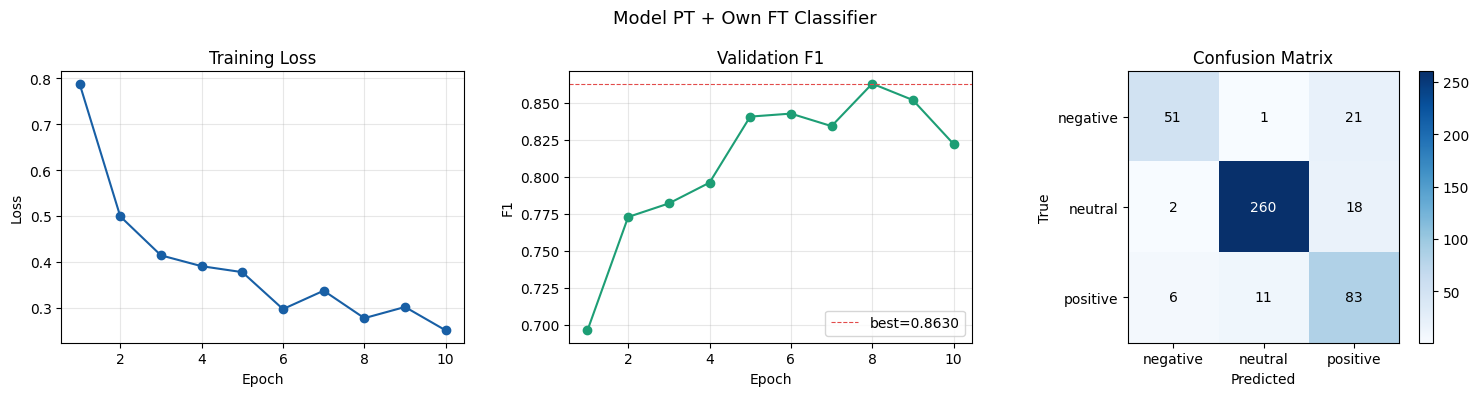

In [23]:

fig, axes = plt.subplots(1, 3, figsize=(15, 4))


axes[0].plot(range(1, EPOCHS_M3+1), train_losses_m3, marker="o", color="#185FA5")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)


axes[1].plot(range(1, EPOCHS_M3+1), val_f1_score_m3, marker="o", color="#1D9E75")
axes[1].axhline(best_val_f1_m3, linestyle="--", color="#E24B4A",
                linewidth=0.8, label=f"best={best_val_f1_m3:.4f}")
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1")
axes[1].legend(); axes[1].grid(alpha=0.3)


cm_m3 = confusion_matrix(all_labels_m3, all_preds_m3)
im    = axes[2].imshow(cm_m3, cmap="Blues")
plt.colorbar(im, ax=axes[2])
axes[2].set_xticks(range(3)); axes[2].set_yticks(range(3))
axes[2].set_xticklabels(label_names); axes[2].set_yticklabels(label_names)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].set_title("Confusion Matrix")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, cm_m3[i, j], ha="center", va="center",
                     color="white" if cm_m3[i, j] > cm_m3.max()/2 else "black")

plt.suptitle("Model PT + Own FT Classifier", fontsize=13)
plt.tight_layout()
plt.show()

# Model 4: Pretrained model + FT Classifier head + FT base

In [24]:
from jax._src.sharding_impls import num_addressable_indices
import copy
model_ft_full=AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_LABELS
)

model_ft_full.load_state_dict(best_state)
model_ft_full.to(device)

for param in model_ft_full.pre_classifier.parameters():
  param.requires_grad=False
for param in model_ft_full.classifier.parameters():
  param.requires_grad=False

for param in model_ft_full.distilbert.parameters():
  param.requires_grad=True

total_params=sum(p.numel() for p in model_ft_full.parameters())
trainable_params=sum(p.numel() for p in model_ft_full.parameters() if p.requires_grad)
frozen_params=total_params-trainable_params

print("=" * 45)
print("  Model 4 parameters")
print("=" * 45)
print(f"  total parameter    : {total_params:,}")
print(f"  trainable parameter  : {trainable_params:,} ")
print(f"  frozen parameter    : {frozen_params:,} ")

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Model 4 parameters
  total parameter    : 66,955,779
  trainable parameter  : 66,362,880 
  frozen parameter    : 592,899 


In [25]:
EPOCHS_M4=5
LR_M4=2e-5

optimizer_m4=AdamW(
    filter(lambda p:p.requires_grad,model_ft_full.parameters()),
    lr=LR_M4,
    weight_decay=0.01
)
scheduler_m4=ReduceLROnPlateau(optimizer_m4,mode="max",patience=2,factor=0.5)
criterion_m4=nn.CrossEntropyLoss()

In [26]:
best_val_f1_m4=0.0
best_state_m4=None
train_losses_m4=[]
val_f1_score_m4=[]

for epoch in range(EPOCHS_M4):
  model_ft_full.train()
  running_loss=0.0

  for batch in train_loader:
    input_ids=batch["input_ids"].to(device)
    attention_mask=batch["attention_mask"].to(device)
    labels=batch["label"].to(device)

    optimizer_m4.zero_grad()
    outputs=model_ft_full(input_ids=input_ids,attention_mask=attention_mask)
    loss=criterion_m4(outputs.logits,labels)
    loss.backward()
    optimizer_m4.step()
    running_loss+=loss.item()

  avg_loss=running_loss/len(train_loader)
  train_losses_m4.append(avg_loss)

  val_acc,val_f1,_,_=evaluate(model_ft_full,val_loader)
  val_f1_score_m4.append(val_f1)
  scheduler_m4.step(val_f1)

  if val_f1>best_val_f1_m4:
    best_val_f1_m4=val_f1
    best_state_m4={k:v.clone() for k,v in model_ft_full.state_dict().items()}

  print(f"Epoch {epoch+1:02d}/{EPOCHS_M4} | "
          f"Loss: {avg_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}"
          + (" ← best" if val_f1 == best_val_f1_m4 else ""))

Epoch 01/5 | Loss: 0.2019 | Val Acc: 0.9341 | Val F1: 0.9336 ← best
Epoch 02/5 | Loss: 0.0554 | Val Acc: 0.9780 | Val F1: 0.9781 ← best
Epoch 03/5 | Loss: 0.0226 | Val Acc: 0.9890 | Val F1: 0.9890 ← best
Epoch 04/5 | Loss: 0.0085 | Val Acc: 0.9890 | Val F1: 0.9890 ← best
Epoch 05/5 | Loss: 0.0065 | Val Acc: 0.9835 | Val F1: 0.9835


In [27]:
model_ft_full.load_state_dict(best_state_m4)

acc_m4,f1_m4,all_labels_m4,all_preds_m4=evaluate(model_ft_full,test_loader)
print("\n" + "=" * 45)
print("  Model PT + FT Classifier + FT Base Valuation")
print("=" * 45)
print(f"  Accuracy : {acc_m4:.4f}")
print(f"  F1 Score : {f1_m4:.4f}")
print()
print(classification_report(all_labels_m4, all_preds_m4, target_names=label_names))

results["Model PT + FT Classifier + FT Base"] = {"accuracy": acc_m4, "f1": f1_m4}


  Model PT + FT Classifier + FT Base Valuation
  Accuracy : 0.9603
  F1 Score : 0.9605

              precision    recall  f1-score   support

    negative       1.00      0.90      0.95        73
     neutral       0.98      0.98      0.98       280
    positive       0.89      0.95      0.92       100

    accuracy                           0.96       453
   macro avg       0.96      0.94      0.95       453
weighted avg       0.96      0.96      0.96       453



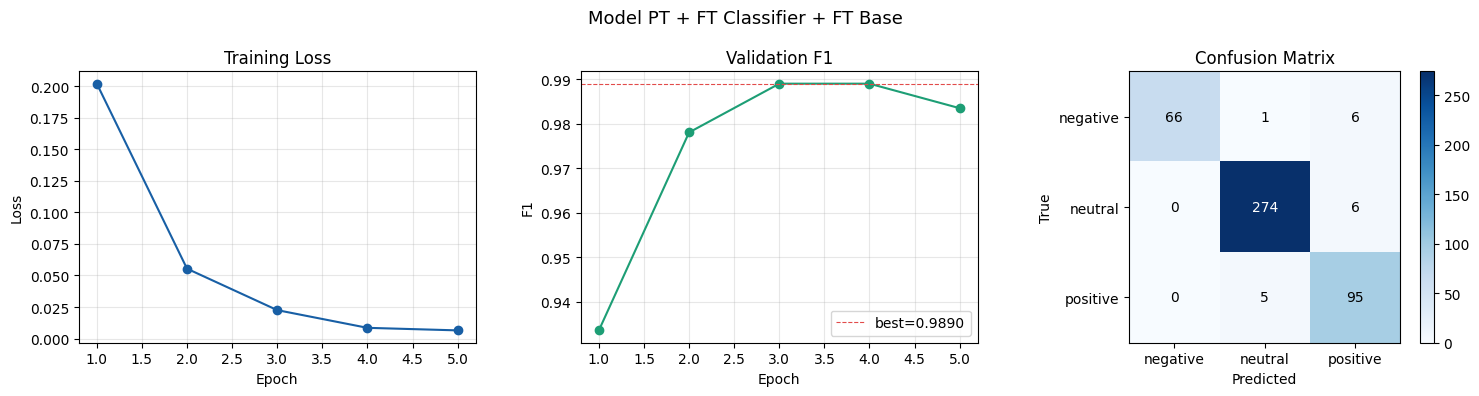

In [28]:
# ── 6. 训练曲线 + 混淆矩阵 ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 左：训练 Loss
axes[0].plot(range(1, EPOCHS_M4+1), train_losses_m4, marker="o", color="#185FA5")
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

# 中：验证 F1
axes[1].plot(range(1, EPOCHS_M4+1), val_f1_score_m4, marker="o", color="#1D9E75")
axes[1].axhline(best_val_f1_m4, linestyle="--", color="#E24B4A",
                linewidth=0.8, label=f"best={best_val_f1_m4:.4f}")
axes[1].set_title("Validation F1")
axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("F1")
axes[1].legend(); axes[1].grid(alpha=0.3)

# 右：混淆矩阵
cm_m4 = confusion_matrix(all_labels_m4, all_preds_m4)
im    = axes[2].imshow(cm_m4, cmap="Blues")
plt.colorbar(im, ax=axes[2])
axes[2].set_xticks(range(3)); axes[2].set_yticks(range(3))
axes[2].set_xticklabels(label_names); axes[2].set_yticklabels(label_names)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].set_title("Confusion Matrix")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, cm_m4[i, j], ha="center", va="center",
                     color="white" if cm_m4[i, j] > cm_m4.max()/2 else "black")

plt.suptitle("Model PT + FT Classifier + FT Base", fontsize=13)
plt.tight_layout()
plt.show()

# Model 5

In [38]:
class LoRALinear(nn.Module):
  def __init__(self,original_linear:nn.Linear,rank:int=8):
    super().__init__()
    self.original=original_linear
    d_out,d_in=original_linear.weight.shape
    self.A=nn.Parameter(torch.randn(rank,d_in)*0.01)
    self.B=nn.Parameter(torch.zeros(d_out,rank))

    for param in self.original.parameters():
      param.requires_grad=False

  def forward(self,x):
    return self.original(x)+(x@self.A.T)@self.B.T

In [39]:
LORA_RANK=8

model_lora=AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=NUM_LABELS)
model_lora.load_state_dict(best_state)

for param in model_lora.parameters():
  param.requires_grad=False

for i,layer in enumerate(model_lora.distilbert.transformer.layer):
  layer.ffn.lin1=LoRALinear(layer.ffn.lin1,rank=LORA_RANK)
  layer.ffn.lin2=LoRALinear(layer.ffn.lin2,rank=LORA_RANK)

model_lora.to(device)

Some weights of DistilBertForSequenceClassification were not initialized from the model checkpoint at distilbert-base-uncased and are newly initialized: ['classifier.bias', 'classifier.weight', 'pre_classifier.bias', 'pre_classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


DistilBertForSequenceClassification(
  (distilbert): DistilBertModel(
    (embeddings): Embeddings(
      (word_embeddings): Embedding(30522, 768, padding_idx=0)
      (position_embeddings): Embedding(512, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
      (dropout): Dropout(p=0.1, inplace=False)
    )
    (transformer): Transformer(
      (layer): ModuleList(
        (0-5): 6 x TransformerBlock(
          (attention): MultiHeadSelfAttention(
            (dropout): Dropout(p=0.1, inplace=False)
            (q_lin): Linear(in_features=768, out_features=768, bias=True)
            (k_lin): Linear(in_features=768, out_features=768, bias=True)
            (v_lin): Linear(in_features=768, out_features=768, bias=True)
            (out_lin): Linear(in_features=768, out_features=768, bias=True)
          )
          (sa_layer_norm): LayerNorm((768,), eps=1e-12, elementwise_affine=True)
          (ffn): FFN(
            (dropout): Dropout(p=0.1, inplace=False)
 

In [40]:
RANK=8
D_MODEL=768
D_FFN=3072
N_LAYERS=6

lora_lin1=RANK*D_MODEL+D_FFN*RANK
lora_lin2=RANK*D_FFN+D_MODEL*RANK
per_layer=lora_lin1+lora_lin2
total_lora=per_layer*N_LAYERS

print("="*50)
print("Calculate the Trainable Parameters of LoRA")
print("="*50)
print(f"LoRA Lin1: {lora_lin1}")
print(f"LoRA Lin2: {lora_lin2}")
print(f"per layer:{per_layer}")
print(f"Total LoRA: {total_lora}")
print()

actual_trainable = sum(p.numel() for p in model_lora.parameters() if p.requires_grad)
print(f"  actual number of trainable weights  : {actual_trainable:,}")
print(f"  same or not           : {'✓ same' if actual_trainable == total_lora else '✗ different'}")

Calculate the Trainable Parameters of LoRA
LoRA Lin1: 30720
LoRA Lin2: 30720
per layer:61440
Total LoRA: 368640

  actual number of trainable weights  : 368,640
  same or not           : ✓ same


In [41]:

EPOCHS_M5 = 5
LR_M5=1e-3

optimizer_m5 = torch.optim.AdamW(
    filter(lambda p: p.requires_grad, model_lora.parameters()),
    lr=LR_M5,
    weight_decay=0.01,
)
scheduler_m5 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_m5, mode="max", patience=1, factor=0.5
)
criterion_m5 = nn.CrossEntropyLoss()

In [42]:
best_val_f1_m5   = 0.0
best_state_m5    = None
train_losses_m5  = []
val_f1_scores_m5 = []

for epoch in range(EPOCHS_M5):
    model_lora.train()
    running_loss = 0.0

    for batch in train_loader:
        input_ids      = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels         = batch["label"].to(device)

        optimizer_m5.zero_grad()
        outputs = model_lora(input_ids=input_ids, attention_mask=attention_mask)
        loss    = criterion_m5(outputs.logits, labels)
        loss.backward()
        optimizer_m5.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses_m5.append(avg_loss)

    val_acc, val_f1, _, _ = evaluate(model_lora, val_loader)
    val_f1_scores_m5.append(val_f1)
    scheduler_m5.step(val_f1)

    if val_f1 > best_val_f1_m5:
        best_val_f1_m5 = val_f1
        best_state_m5  = {k: v.clone() for k, v in model_lora.state_dict().items()}

    print(f"Epoch {epoch+1:02d}/{EPOCHS_M5} | "
          f"Loss: {avg_loss:.4f} | "
          f"Val Acc: {val_acc:.4f} | "
          f"Val F1: {val_f1:.4f}"
          + (" ← best" if val_f1 == best_val_f1_m5 else ""))

Epoch 01/5 | Loss: 0.1682 | Val Acc: 0.9615 | Val F1: 0.9609 ← best
Epoch 02/5 | Loss: 0.0840 | Val Acc: 0.9780 | Val F1: 0.9781 ← best
Epoch 03/5 | Loss: 0.0393 | Val Acc: 0.9780 | Val F1: 0.9782 ← best
Epoch 04/5 | Loss: 0.0334 | Val Acc: 0.9780 | Val F1: 0.9782 ← best
Epoch 05/5 | Loss: 0.0154 | Val Acc: 0.9780 | Val F1: 0.9781


In [43]:
model_lora.load_state_dict(best_state_m5)

acc_m5, f1_m5, all_labels_m5, all_preds_m5 = evaluate(model_lora, test_loader)

print("\n" + "=" * 50)
print("  Model PT + FT Classifier + PEFT Base Valuation")
print("=" * 50)
print(f"  Accuracy : {acc_m5:.4f}")
print(f"  F1 Score : {f1_m5:.4f}")
print()
print(classification_report(all_labels_m5, all_preds_m5, target_names=label_names))

results["Model PT + FT Classifier + PEFT Base"] = {"accuracy": acc_m5, "f1": f1_m5}


  Model PT + FT Classifier + PEFT Base Valuation
  Accuracy : 0.9581
  F1 Score : 0.9582

              precision    recall  f1-score   support

    negative       0.96      0.92      0.94        73
     neutral       0.98      0.97      0.98       280
    positive       0.90      0.94      0.92       100

    accuracy                           0.96       453
   macro avg       0.95      0.94      0.95       453
weighted avg       0.96      0.96      0.96       453



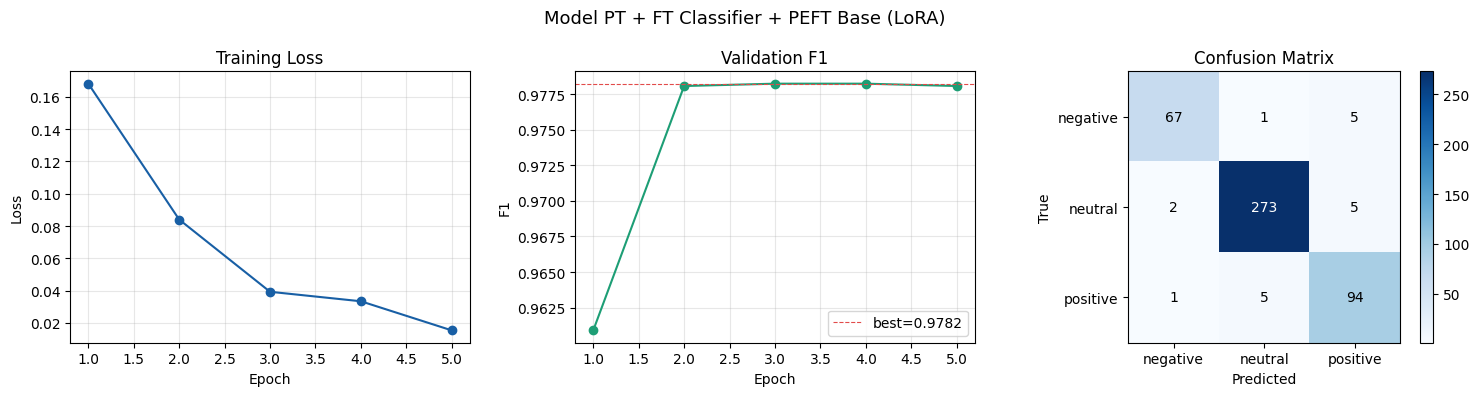

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(range(1, EPOCHS_M5+1), train_losses_m5, marker="o", color="#185FA5")
axes[0].set_title("Training Loss"); axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss"); axes[0].grid(alpha=0.3)

axes[1].plot(range(1, EPOCHS_M5+1), val_f1_scores_m5, marker="o", color="#1D9E75")
axes[1].axhline(best_val_f1_m5, linestyle="--", color="#E24B4A",
                linewidth=0.8, label=f"best={best_val_f1_m5:.4f}")
axes[1].set_title("Validation F1"); axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("F1"); axes[1].legend(); axes[1].grid(alpha=0.3)

cm_m5 = confusion_matrix(all_labels_m5, all_preds_m5)
im    = axes[2].imshow(cm_m5, cmap="Blues")
plt.colorbar(im, ax=axes[2])
axes[2].set_xticks(range(3)); axes[2].set_yticks(range(3))
axes[2].set_xticklabels(label_names); axes[2].set_yticklabels(label_names)
axes[2].set_xlabel("Predicted"); axes[2].set_ylabel("True")
axes[2].set_title("Confusion Matrix")
for i in range(3):
    for j in range(3):
        axes[2].text(j, i, cm_m5[i, j], ha="center", va="center",
                     color="white" if cm_m5[i, j] > cm_m5.max()/2 else "black")

plt.suptitle("Model PT + FT Classifier + PEFT Base (LoRA)", fontsize=13)
plt.tight_layout()
plt.show()

In [45]:
print("\nCompare all models：")
print(f"{'model':<45} {'Accuracy':>10} {'F1':>10}")
print("-" * 67)
for name, m in results.items():
    print(f"{name:<45} {m['accuracy']:>10.4f} {m['f1']:>10.4f}")


Compare all models：
model                                           Accuracy         F1
-------------------------------------------------------------------
Model PT                                          0.3355     0.3530
Model PT + FT Classifier                          0.8720     0.8722
Model PT + Own FT Classifier                      0.8698     0.8719
Model PT + FT Classifier + FT Base                0.9603     0.9605
Model PT + FT Classifier + PEFT Base              0.9581     0.9582
